# Radio cross-match

Cross-match the OVRO-LWA metacatalog against external radio reference catalogs. Matching is most reliable at similar frequency and angular resolution:

| Catalog | Frequency | Beam | Role |
| --- | --- | --- | --- |
| VLSSR | ~74 MHz | 80″ | 73 MHz subband merge QA (similar freq/resolution) |
| [NVSS](https://heasarc.gsfc.nasa.gov/w3browse/all/nvss.html) | 1.4 GHz | 45″ | Known-source association (Condon et al. 1998) |
| [VLASS QL epoch 1](https://cirada.ca/catalogues) | ~3 GHz | ~2.5″ | Known-source association (Gordon et al. 2021, [ApJS 255, 30](https://scixplorer.org/abs/2021ApJS..255...30G/abstract)) |

Reference catalog files live under `/fast/claw/catalogs/` (see `REFERENCE_CATALOGS_DIR` in `lwa_catalog.constants`).

**Matching:** configurable radius per side (LWA + reference), then pairwise
``sep ≤ max(radius_lwa, radius_ref)`` via ``associate_catalogs``. See
``CrossmatchRadiusSpec`` in the config cell (`mode`: ``beam`` | ``localization`` | ``fixed``).

**Flux comparisons:** prefer **total flux** on both sides when available (LWA `Total_flux_{band}`, VLASS `Total_flux`). VLSSR only publishes peak intensity (peak comparisons). NVSS VizieR VIII/65 publishes integrated ``S1.4`` in mJy (converted to Jy). CIRADA VLASS `Peak_flux` / `Total_flux` are mJy in the component CSV (converted to Jy on load).

**Cascaded bootstrap:** QA matches run VLSSR → NVSS → VLASS, adopting bijective VLSSR then NVSS positions/errors on the match frame (metacatalog `RA`/`DEC` unchanged).

**Photometric attach:** after the QA matches, `attach_radio_surveys_to_metacatalog(..., cascade_bootstrap=True)` writes `Peak_flux_{survey}` / `Total_flux_{survey}` / `n_assoc_{survey}` onto existing LWA rows only (brightest hit prefers total flux; no unmatched survey seeds; LWA astrometry unchanged).

**Cached mode:** `USE_CACHED_CROSSMATCH = True` skips metacatalog load, VLSSR/NVSS/VLASS match, attach, and write (safe for Run All). Visual QA reads `metacatalog_radio.parquet`. Set it `False` to recompute the cross-match.

**Run cells in order.**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog, resolve_metacatalog_path
from lwa_catalog.io import write_table
from lwa_catalog.analyze import (
    CrossmatchRadiusSpec,
    LWA_CROSSMATCH_RADIUS_BEAM,
    LWA_CROSSMATCH_RADIUS_LOCALIZATION,
    NVSS_REFERENCE_RADIUS_LOCALIZATION,
    VLASS_REFERENCE_RADIUS_LOCALIZATION,
    VLSSR_REFERENCE_RADIUS_FIXED,
    NvssMatchConfig,
    VlassMatchConfig,
    VlssrMatchConfig,
    attach_radio_surveys_to_metacatalog,
    advance_from_match,
    bootstrap_source_counts,
    native_lwa_frame,
    describe_crossmatch_radius,
    load_nvss_catalog,
    load_vlass_catalog,
    load_vlssr_catalog,
    match_catalog_to_nvss,
    match_catalog_to_vlass,
    match_catalog_to_vlssr,
    predict_flux_at_frequency_hz,
    resolve_band_flux,
    resolve_highest_frequency_flux,
    resolve_row_flux,
    summarize_nvss_match,
    summarize_vlass_match,
    summarize_vlssr_match,
)
from lwa_catalog.constants import (
    NVSS_BMAJ_ARCSEC,
    NVSS_DEFAULT_PATH,
    NVSS_FREQ_HZ,
    REFERENCE_CATALOGS_DIR,
    VLASS_BMAJ_ARCSEC,
    VLASS_DEFAULT_PATH,
    VLASS_FREQ_HZ,
    VLSSR_BMAJ_ARCSEC,
    VLSSR_DEFAULT_PATH,
    VLSSR_FREQ_HZ,
    band_frequency_hz,
)

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_coaddR-0.75_subband2")
VLSSR_PATH = VLSSR_DEFAULT_PATH
NVSS_PATH = NVSS_DEFAULT_PATH
VLASS_PATH = VLASS_DEFAULT_PATH
QUALITY_FLAG_MASK = 33267  # HAS_NAN|INVALID_ASTROMETRY|UNPHYSICAL_FLUX|RESID_ABS_FAIL|RESID_PCTL_RMS|RESID_PCTL_MEAN|JITTER_FAIL|LARGE_SINGLE; set None to keep all rows
WRITE_CROSSMATCH = True  # write metacatalog_radio.parquet after survey attach
USE_CACHED_CROSSMATCH = False  # True: skip load/match/attach/write; Visual QA reads metacatalog_radio.parquet

# Subband nearest VLSSR (~74 MHz) for native flux comparison.
VLSSR_LWA_BAND = "73MHz"

# --- cross-match radius (per catalog side) ---
# mode "beam"           — restoring beam (BMAJ_match / BMAJ); default for surveys
# mode "localization"   — 1σ position error (E_RA/E_DEC, cluster_jitter_rms_deg, or default_arcsec)
# mode "fixed"          — constant fixed_arcsec for every source
# sigma_scale           — multiply beam or 1σ radius (e.g. 3 for 3σ matching)

#LWA_MATCH_RADIUS = LWA_CROSSMATCH_RADIUS_BEAM
#LWA_MATCH_RADIUS = LWA_CROSSMATCH_RADIUS_LOCALIZATION
LWA_MATCH_RADIUS = CrossmatchRadiusSpec(mode="localization", sigma_scale=3.0)

VLSSR_REFERENCE_RADIUS = VLSSR_REFERENCE_RADIUS_FIXED
#VLSSR_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=VLSSR_BMAJ_ARCSEC)

#NVSS_REFERENCE_RADIUS = NVSS_REFERENCE_RADIUS_LOCALIZATION
# NVSS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=NVSS_BMAJ_ARCSEC)
NVSS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="localization", sigma_scale=3.0)

#VLASS_REFERENCE_RADIUS = VLASS_REFERENCE_RADIUS_LOCALIZATION
# VLASS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="fixed", fixed_arcsec=VLASS_BMAJ_ARCSEC)
VLASS_REFERENCE_RADIUS = CrossmatchRadiusSpec(mode="localization", sigma_scale=3.0)

layout = CatalogLayout(CATALOG_DIR)
vlssr_config = VlssrMatchConfig(
    catalog_path=VLSSR_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=VLSSR_REFERENCE_RADIUS,
)
nvss_config = NvssMatchConfig(
    catalog_path=NVSS_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=NVSS_REFERENCE_RADIUS,
)
vlass_config = VlassMatchConfig(
    catalog_path=VLASS_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=VLASS_REFERENCE_RADIUS,
)

print("CATALOG_DIR =", layout.root.resolve())
print("metacatalog path =", resolve_metacatalog_path(layout))
print("REFERENCE_CATALOGS_DIR =", REFERENCE_CATALOGS_DIR.resolve())
print("VLSSR_PATH =", Path(VLSSR_PATH).resolve())
print("NVSS_PATH =", Path(NVSS_PATH).resolve())
print("VLASS_PATH =", Path(VLASS_PATH).resolve())
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("VLSSR_LWA_BAND =", VLSSR_LWA_BAND)
print("WRITE_CROSSMATCH =", WRITE_CROSSMATCH)
print("USE_CACHED_CROSSMATCH =", USE_CACHED_CROSSMATCH)
print(
    "cached radio parquet exists:" if layout.metacatalog_radio().is_file()
    else "cached radio parquet MISSING:",
    layout.metacatalog_radio().resolve(),
)
print("CROSSMATCH_OUTPUT =", layout.metacatalog_radio().resolve())
print("LWA match radius:", describe_crossmatch_radius(LWA_MATCH_RADIUS))
print("VLSSR reference radius:", describe_crossmatch_radius(VLSSR_REFERENCE_RADIUS))
print("NVSS reference radius:", describe_crossmatch_radius(NVSS_REFERENCE_RADIUS))
print("VLASS reference radius:", describe_crossmatch_radius(VLASS_REFERENCE_RADIUS))

if USE_CACHED_CROSSMATCH:
    print(
        "USE_CACHED_CROSSMATCH=True → skip metacatalog load, VLSSR/NVSS/VLASS match, "
        "attach, and write. Jump to Visual QA (or Run All; those cells no-op)."
    )
else:
    print("USE_CACHED_CROSSMATCH=False → full cross-match pipeline will run.")


CATALOG_DIR = /fast/claw/metacatalog_coaddR-0.75_subband2
metacatalog path = /fast/claw/metacatalog_coaddR-0.75_subband2/metacatalog_quality.parquet
REFERENCE_CATALOGS_DIR = /fast/claw/catalogs
VLSSR_PATH = /fast/claw/catalogs/vlssr_radecpeak.txt
NVSS_PATH = /fast/claw/catalogs/nvss/nvss_vizier.parquet
VLASS_PATH = /fast/claw/catalogs/vlass/CIRADA_VLASS1QLv3.1_table1_components.csv
QUALITY_FLAG_MASK = 33267
VLSSR_LWA_BAND = 73MHz
WRITE_CROSSMATCH = True
USE_CACHED_CROSSMATCH = False
cached radio parquet MISSING: /fast/claw/metacatalog_coaddR-0.75_subband2/metacatalog_radio.parquet
CROSSMATCH_OUTPUT = /fast/claw/metacatalog_coaddR-0.75_subband2/metacatalog_radio.parquet
LWA match radius: localization (E_RA/E_DEC or jitter) × 3σ
VLSSR reference radius: fixed 3.0″
NVSS reference radius: localization (E_RA/E_DEC or jitter) × 3σ
VLASS reference radius: localization (E_RA/E_DEC or jitter) × 3σ
USE_CACHED_CROSSMATCH=False → full cross-match pipeline will run.


## Load metacatalog

Reads ``metacatalog_quality.parquet`` (quality-flagged fusion product). Every quality-cleared row is used for VLSSR / NVSS / VLASS; there is no Blue-band subset.

Skipped when ``USE_CACHED_CROSSMATCH=True``.


In [2]:
if USE_CACHED_CROSSMATCH:
    print("Skipping metacatalog load (USE_CACHED_CROSSMATCH=True)")
else:
    metacatalog = read_metacatalog(
        layout,
        prefer_quality=True,
        prefer_spectral=False,
        quality_mask=QUALITY_FLAG_MASK,
    )

    print(f"metacatalog rows: {len(metacatalog)}")
    print(f"quality_flag present: {'quality_flag' in metacatalog.columns}")
    print(f"spectral columns present: {any(c.startswith('spec_peak_') for c in metacatalog.columns)}")
    print(f"Peak_flux_{VLSSR_LWA_BAND} present: {f'Peak_flux_{VLSSR_LWA_BAND}' in metacatalog.columns}")
    print(f"Total_flux_{VLSSR_LWA_BAND} present: {f'Total_flux_{VLSSR_LWA_BAND}' in metacatalog.columns}")


metacatalog rows: 252104
quality_flag present: True
spectral columns present: False
Peak_flux_73MHz present: True
Total_flux_73MHz present: True


In [3]:
def build_unique_flux_table(
    selected_meta: pd.DataFrame,
    meta_flags: pd.DataFrame,
    ref_footprint: pd.DataFrame,
    *,
    count_col: str,
    positions_col: str,
    ref_freq_hz: float,
    lwa_flux_col: str,
) -> pd.DataFrame:
    """Build unique 1:1 matches with survey flux, native LWA flux, and extrapolated flux.

    Prefers total flux on both sides when available (falls back to peak).
    ``lwa_flux_jy`` is the highest-frequency LWA flux on the row.
    ``{lwa_flux_col}`` is the spectral-model extrapolation to ``ref_freq_hz``
    when ``spec_*`` columns exist (else NaN).
    """
    unique_flags = meta_flags.loc[meta_flags[count_col] == 1].copy()
    meta_by_id = selected_meta.set_index("meta_id", drop=False)
    records: list[dict] = []
    for _, flag in unique_flags.iterrows():
        positions = flag.get(positions_col, [])
        if len(positions) != 1:
            continue
        meta_id = flag["meta_id"]
        if meta_id not in meta_by_id.index:
            continue
        meta_row = meta_by_id.loc[meta_id]
        if isinstance(meta_row, pd.DataFrame):
            meta_row = meta_row.iloc[0]
        ref_row = ref_footprint.iloc[int(positions[0])]
        ref_flux = resolve_row_flux(ref_row, prefer_total=True)
        lwa_native, _, _ = resolve_highest_frequency_flux(meta_row, prefer_total=True)
        lwa_extrap = predict_flux_at_frequency_hz(
            meta_row, ref_freq_hz, flux_kind="total"
        )
        records.append(
            {
                "meta_id": meta_id,
                "RA": flag["RA"],
                "DEC": flag["DEC"],
                "ref_flux_jy": ref_flux,
                "lwa_flux_jy": lwa_native,
                lwa_flux_col: lwa_extrap,
                "log_ratio_native": (
                    np.log10(lwa_native / ref_flux)
                    if np.isfinite(lwa_native) and ref_flux > 0
                    else np.nan
                ),
                "log_ratio_extrap": (
                    np.log10(lwa_extrap / ref_flux)
                    if np.isfinite(lwa_extrap) and ref_flux > 0
                    else np.nan
                ),
            }
        )
    return pd.DataFrame.from_records(records)


def plot_unique_flux_check(
    flux_table: pd.DataFrame,
    *,
    title: str,
    lwa_flux_col: str,
    ref_label: str,
    ref_freq_hz: float | None = None,
) -> None:
    """Plot log10 LWA flux vs log10 survey flux for unique matches.

    Prefers spectral extrapolation to ``ref_freq_hz`` when available; otherwise
    falls back to the native highest-frequency LWA flux (total preferred).
    """
    use_extrap = (
        lwa_flux_col in flux_table.columns
        and flux_table[lwa_flux_col].notna().any()
    )
    if use_extrap:
        y_col = lwa_flux_col
        ratio_col = "log_ratio_extrap"
        freq = "" if ref_freq_hz is None else f" @ {ref_freq_hz / 1e9:.2f} GHz"
        y_label = f"log10 LWA extrapolated flux{freq}"
        mode = "extrapolated"
    else:
        y_col = "lwa_flux_jy"
        ratio_col = "log_ratio_native"
        y_label = "log10 LWA native flux (Jy)"
        mode = "native (no spec_* columns)"

    finite = flux_table.dropna(subset=[ratio_col])
    if finite.empty:
        print(f"No finite LWA vs {ref_label} flux pairs for plot ({mode}).")
        return

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(
        np.log10(finite["ref_flux_jy"]),
        np.log10(finite[y_col]),
        s=8,
        alpha=0.35,
    )
    lim = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1]),
    ]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel(f"log10 {ref_label} flux (Jy)")
    ax.set_ylabel(y_label)
    ax.set_title(f"{title} [{mode}]")
    plt.show()
    print(
        f"plotted {len(finite)} unique matches "
        f"(median log10 LWA/{ref_label} = {finite[ratio_col].median():+.3f})"
    )


## VLSSR cross-match (~74 MHz)

Post-hoc QA against the VLSSR reference catalog at similar frequency and resolution to the **73 MHz** subband.

**Primary metric:** completeness — fraction of quality-cleared metacatalog rows that match ≥1 VLSSR source within the match radius.

**Failure-mode metric:** VLSSR over-splitting — one VLSSR source matched by multiple metacatalog rows.

Skipped when ``USE_CACHED_CROSSMATCH=True``.


In [4]:
if USE_CACHED_CROSSMATCH:
    print("Skipping VLSSR cross-match (USE_CACHED_CROSSMATCH=True)")
else:
    vlssr = load_vlssr_catalog(VLSSR_PATH)
    print(f"VLSSR rows: {len(vlssr):,}")
    vlssr_result = match_catalog_to_vlssr(metacatalog, vlssr=vlssr, config=vlssr_config)
    bootstrap_frame = native_lwa_frame(metacatalog, LWA_MATCH_RADIUS)
    bootstrap_frame = advance_from_match(
        bootstrap_frame, vlssr_result, VLSSR_REFERENCE_RADIUS, source="VLSSR"
    )
    print("Bootstrap after VLSSR:", bootstrap_source_counts(bootstrap_frame))
    print(summarize_vlssr_match(vlssr_result))


VLSSR rows: 92,965
Bootstrap after VLSSR: {'LWA': 193820, 'VLSSR': 58284}
LWA target rows:              252104
VLSSR footprint (Dec box):     92965
Meta matched (>=1 VLSSR):      68994
Blue completeness:            0.274
VLSSR matched (>=1 meta):      75137
VLSSR recovery:               0.808
VLSSR over-split (n_meta>1):    4222
Meta multi-VLSSR (n_vlssr>1):   8166
Max VLSSR hits per meta:          17


In [5]:
if USE_CACHED_CROSSMATCH:
    print("Skipping VLSSR match QA tables (USE_CACHED_CROSSMATCH=True)")
else:
    vlssr_meta_flags = vlssr_result.meta_flags
    vlssr_ref_flags = vlssr_result.vlssr_flags

    print("VLSSR hits per meta (value_counts):")
    display(vlssr_meta_flags["n_vlssr"].value_counts().sort_index().head(20))

    vlssr_incomplete = vlssr_meta_flags.loc[~vlssr_meta_flags["matched"]]
    print(f"\nIncomplete metacatalog rows (no VLSSR match, first 20 of {len(vlssr_incomplete)}):")
    display(vlssr_incomplete.head(20))

    vlssr_oversplit = vlssr_ref_flags.loc[vlssr_ref_flags["oversplit"]]
    print(f"\nVLSSR over-split rows (first 20 of {len(vlssr_oversplit)}):")
    display(vlssr_oversplit.head(20))


VLSSR hits per meta (value_counts):


n_vlssr
0     183110
1      60828
2       6477
3       1254
4        298
5         89
6         33
7          6
8          4
10         3
17         2
Name: count, dtype: int64


Incomplete metacatalog rows (no VLSSR match, first 20 of 183110):


,meta_id,RA,DEC,n_vlssr,vlssr_positions,matched
0,2681,69.235713,29.486041,0,[],False
1,4138,69.480906,29.510522,0,[],False
2,258035,68.974885,29.509347,0,[],False
3,257982,69.231894,29.886232,0,[],False
4,261340,6.054178,64.432851,0,[],False
5,178631,260.351522,-1.022700,0,[],False
6,30253,303.237997,23.476486,0,[],False
7,179469,303.326568,23.650336,0,[],False
8,186903,303.315209,23.380789,0,[],False
9,3961,303.293246,23.797484,0,[],False



VLSSR over-split rows (first 20 of 4222):


,vlssr_pos,RA,DEC,Peak_flux,n_meta,meta_ids,oversplit
7,7,0.019321,31.791324,0.468295,2,"[199238, 106386]",True
8,8,0.022301,43.725057,0.471617,2,"[155555, 207626]",True
43,43,0.115188,20.598451,0.849489,2,"[3723, 193679]",True
169,169,0.466498,44.790947,0.521183,2,"[201629, 38383]",True
212,212,0.597957,9.004754,0.779255,2,"[64918, 69195]",True
240,240,0.690242,12.452433,0.396204,2,"[206227, 92911]",True
282,282,0.818650,8.941644,0.860676,2,"[189101, 69195]",True
289,289,0.835667,9.307707,0.633207,2,"[105301, 189101]",True
303,303,0.862651,30.095824,2.359415,2,"[115026, 17712]",True
314,314,0.906796,9.083188,1.208067,2,"[189101, 69195]",True


unique VLSSR matches: 60828
with LWA 73MHz total/peak flux: 57129
LWA total column present: True
LWA peak column present: True


,meta_id,vlssr_flux_jy,lwa_flux_73mhz_jy,log_ratio
0,179510,1.093618,NaN,NaN
1,79288,1.297089,0.920456,-0.148967
2,251056,68.773331,0.412570,-2.221922
3,236255,0.832659,0.998037,0.078679
4,32131,1.858513,NaN,NaN
5,73359,0.764505,NaN,NaN
6,99667,0.560668,1.340514,0.378566
7,16028,3.209942,3.882983,0.082668
8,454,17.341331,7.609853,-0.357706
9,1263,1.082248,11.875738,1.040334


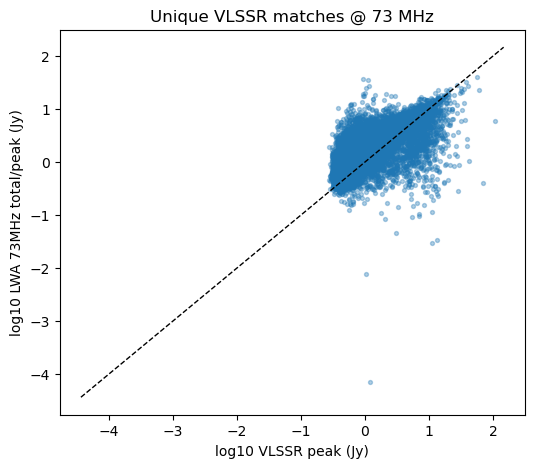

In [6]:
if USE_CACHED_CROSSMATCH:
    print("Skipping VLSSR flux check (USE_CACHED_CROSSMATCH=True)")
else:
    vlssr_total_col = f"Total_flux_{VLSSR_LWA_BAND}"
    vlssr_peak_col = f"Peak_flux_{VLSSR_LWA_BAND}"
    vlssr_freq_hz = band_frequency_hz(VLSSR_LWA_BAND)
    meta_by_id = metacatalog.set_index("meta_id", drop=False)
    vlssr_unique = vlssr_meta_flags.loc[vlssr_meta_flags["n_vlssr"] == 1].copy()

    vlssr_flux_records: list[dict] = []
    for _, flag in vlssr_unique.iterrows():
        positions = flag.get("vlssr_positions", [])
        if len(positions) != 1:
            continue
        meta_id = flag["meta_id"]
        if meta_id not in meta_by_id.index:
            continue
        meta_row = meta_by_id.loc[meta_id]
        if isinstance(meta_row, pd.DataFrame):
            meta_row = meta_row.iloc[0]
        ref_row = vlssr_result.vlssr_footprint.iloc[int(positions[0])]
        # VLSSR publishes peak intensity only.
        ref_flux = resolve_row_flux(ref_row, prefer_total=True)
        lwa_flux = resolve_band_flux(meta_row, VLSSR_LWA_BAND, prefer_total=True)
        if not np.isfinite(lwa_flux) or lwa_flux <= 0.0:
            lwa_flux = float(
                predict_flux_at_frequency_hz(meta_row, VLSSR_FREQ_HZ, flux_kind="total")
            )
        vlssr_flux_records.append(
            {
                "meta_id": meta_id,
                "vlssr_flux_jy": ref_flux,
                "lwa_flux_73mhz_jy": lwa_flux,
                "log_ratio": np.log10(lwa_flux / ref_flux)
                if np.isfinite(lwa_flux) and ref_flux > 0
                else np.nan,
            }
        )

    vlssr_flux_table = pd.DataFrame.from_records(vlssr_flux_records)
    print(f"unique VLSSR matches: {len(vlssr_unique)}")
    print(
        f"with LWA {VLSSR_LWA_BAND} total/peak flux: "
        f"{vlssr_flux_table['lwa_flux_73mhz_jy'].notna().sum()}"
    )
    print(f"LWA total column present: {vlssr_total_col in metacatalog.columns}")
    print(f"LWA peak column present: {vlssr_peak_col in metacatalog.columns}")
    display(vlssr_flux_table.head(20))

    finite = vlssr_flux_table.dropna(subset=["log_ratio"])
    if not finite.empty:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(
            np.log10(finite["vlssr_flux_jy"]),
            np.log10(finite["lwa_flux_73mhz_jy"]),
            s=8,
            alpha=0.35,
        )
        lim = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1]),
        ]
        ax.plot(lim, lim, "k--", lw=1)
        ax.set_xlabel("log10 VLSSR peak (Jy)")
        ax.set_ylabel(f"log10 LWA {VLSSR_LWA_BAND} total/peak (Jy)")
        ax.set_title(f"Unique VLSSR matches @ {vlssr_freq_hz / 1e6:.0f} MHz")
        plt.show()


## NVSS cross-match (1.4 GHz)

Loads ~1.8M rows from the NRAO FITS table (30–60 s on first read).

Skipped when ``USE_CACHED_CROSSMATCH=True``.


In [7]:
if USE_CACHED_CROSSMATCH:
    print("Skipping NVSS cross-match (USE_CACHED_CROSSMATCH=True)")
else:
    nvss = load_nvss_catalog(NVSS_PATH)
    print(f"NVSS rows: {len(nvss):,}")
    print(f"Dec range: {nvss['DEC'].min():.2f} .. {nvss['DEC'].max():.2f}")
    nvss_result = match_catalog_to_nvss(
        metacatalog, nvss=nvss, config=nvss_config, lwa_match=bootstrap_frame
    )
    bootstrap_frame = advance_from_match(
        bootstrap_frame, nvss_result, NVSS_REFERENCE_RADIUS, source="NVSS"
    )
    print("Bootstrap after NVSS:", bootstrap_source_counts(bootstrap_frame))
    print(summarize_nvss_match(nvss_result))


NVSS rows: 1,773,484
Dec range: -40.43 .. 89.82
Bootstrap after NVSS: {'LWA': 170643, 'VLSSR': 49988, 'NVSS': 31473}
LWA target rows:              252104
NVSS footprint (Dec box):     1770351
Meta matched (>=1 NVSS):       72123
Match completeness:           0.286
Meta unique match (n=1):       32879
Unique match fraction:        0.130
NVSS matched (>=1 meta):      176041
NVSS recovery:                0.099
NVSS over-split (n_meta>1):    15249
Meta multi-NVSS (n_nvss>1):    39244
Max NVSS hits per meta:           42

NVSS reference frequency:     1.40 GHz


In [8]:
if USE_CACHED_CROSSMATCH:
    print("Skipping NVSS match QA tables (USE_CACHED_CROSSMATCH=True)")
else:
    nvss_meta_flags = nvss_result.meta_flags
    nvss_flags = nvss_result.nvss_flags

    print("NVSS hits per meta (value_counts):")
    display(nvss_meta_flags["n_nvss"].value_counts().sort_index().head(20))

    nvss_unmatched = nvss_meta_flags.loc[~nvss_meta_flags["matched"]]
    print(f"\nUnmatched meta rows (first 20 of {len(nvss_unmatched)}):")
    display(nvss_unmatched.head(20))


NVSS hits per meta (value_counts):


n_nvss
0     179981
1      32879
2      15825
3       8641
4       4787
5       2752
6       1752
7       1218
8        890
9        701
10       549
11       499
12       357
13       282
14       224
15       171
16       139
17        99
18        89
19        61
Name: count, dtype: int64


Unmatched meta rows (first 20 of 179981):


,meta_id,RA,DEC,n_nvss,nvss_positions,matched
0,2681,69.235713,29.486041,0,[],False
3,257982,69.231894,29.886232,0,[],False
6,30253,303.237997,23.476486,0,[],False
7,179469,303.326568,23.650336,0,[],False
8,186903,303.315209,23.380789,0,[],False
9,3961,303.293246,23.797484,0,[],False
10,180619,303.419388,23.466691,0,[],False
11,92391,226.344390,26.322007,0,[],False
13,263594,226.311687,25.729188,0,[],False
15,27553,226.225495,25.813857,0,[],False


unique NVSS matches: 32879
with LWA native flux: 32879
with spectral extrapolation to 1.4 GHz: 0


,meta_id,RA,DEC,ref_flux_jy,lwa_flux_jy,lwa_flux_1p4ghz_jy,log_ratio_native,log_ratio_extrap
0,258035,68.974885,29.509347,0.0029,18.202794,NaN,3.797740,NaN
1,9471,226.458739,25.805159,0.0258,5.806082,NaN,2.352263,NaN
2,79288,247.534635,39.368311,0.1750,1.689325,NaN,0.984675,NaN
3,202886,246.850142,39.266480,0.0140,0.594781,NaN,1.628229,NaN
4,200056,247.321857,39.854003,0.0333,0.598620,NaN,1.254707,NaN
5,15569,262.860200,-21.551629,0.0048,3.801951,NaN,2.898765,NaN
6,10418,262.681143,-21.162834,0.0087,5.171310,NaN,2.774081,NaN
7,99667,294.969325,21.937383,0.0625,1.355252,NaN,1.336140,NaN
8,258777,333.394148,-16.955192,0.0032,4.944196,NaN,3.188946,NaN
9,76242,35.733109,43.188201,0.0282,0.692950,NaN,1.390453,NaN


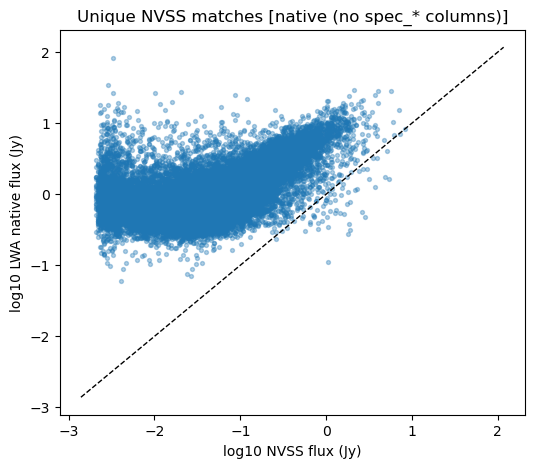

plotted 32879 unique matches (median log10 LWA/NVSS = +1.232)


In [9]:
if USE_CACHED_CROSSMATCH:
    print("Skipping NVSS flux check (USE_CACHED_CROSSMATCH=True)")
else:
    nvss_flux_table = build_unique_flux_table(
        metacatalog,
        nvss_meta_flags,
        nvss_result.nvss_footprint,
        count_col="n_nvss",
        positions_col="nvss_positions",
        ref_freq_hz=NVSS_FREQ_HZ,
        lwa_flux_col="lwa_flux_1p4ghz_jy",
    )
    print(f"unique NVSS matches: {(nvss_meta_flags['n_nvss'] == 1).sum()}")
    print(f"with LWA native flux: {nvss_flux_table['lwa_flux_jy'].notna().sum()}")
    print(
        "with spectral extrapolation to 1.4 GHz: "
        f"{nvss_flux_table['lwa_flux_1p4ghz_jy'].notna().sum()}"
    )
    display(nvss_flux_table.head(20))
    plot_unique_flux_check(
        nvss_flux_table,
        title="Unique NVSS matches",
        lwa_flux_col="lwa_flux_1p4ghz_jy",
        ref_label="NVSS",
        ref_freq_hz=NVSS_FREQ_HZ,
    )


## VLASS cross-match (~3 GHz)

Loads the CIRADA QL epoch 1 component CSV (plain `.csv` or `.csv.gz`) with recommended quality flags (`Duplicate_flag <= 1`, `Quality_flag in (0, 4)`, `S_Code != 'E'`). CIRADA `Peak_flux` / `Total_flux` are in mJy and converted to Jy on load. First read can take several minutes.

Skipped when ``USE_CACHED_CROSSMATCH=True``.


In [10]:
if USE_CACHED_CROSSMATCH:
    print("Skipping VLASS cross-match (USE_CACHED_CROSSMATCH=True)")
else:
    vlass = load_vlass_catalog(VLASS_PATH, config=vlass_config)
    print(f"VLASS rows (after quality filter): {len(vlass):,}")
    print(f"Dec range: {vlass['DEC'].min():.2f} .. {vlass['DEC'].max():.2f}")
    vlass_result = match_catalog_to_vlass(
        metacatalog, vlass=vlass, config=vlass_config, lwa_match=bootstrap_frame
    )
    print("Bootstrap for VLASS (from NVSS cascade):", bootstrap_source_counts(bootstrap_frame))
    print(summarize_vlass_match(vlass_result))


VLASS rows (after quality filter): 1,874,645
Dec range: -40.02 .. 89.82
Bootstrap for VLASS (from NVSS cascade): {'LWA': 170643, 'VLSSR': 49988, 'NVSS': 31473}
LWA target rows:              252104
VLASS footprint (Dec box):    1874458
Meta matched (>=1 VLASS):      59639
Match completeness:           0.237
Meta unique match (n=1):       23865
Unique match fraction:        0.095
VLASS matched (>=1 meta):     188298
VLASS recovery:               0.100
VLASS over-split (n_meta>1):   20093
Meta multi-VLASS (n_vlass>1):  35774
Max VLASS hits per meta:          42

VLASS reference frequency:    3.00 GHz


In [11]:
if USE_CACHED_CROSSMATCH:
    print("Skipping VLASS match QA tables (USE_CACHED_CROSSMATCH=True)")
else:
    vlass_meta_flags = vlass_result.meta_flags
    vlass_ref_flags = vlass_result.vlass_flags

    print("VLASS hits per meta (value_counts):")
    display(vlass_meta_flags["n_vlass"].value_counts().sort_index().head(20))

    vlass_unmatched = vlass_meta_flags.loc[~vlass_meta_flags["matched"]]
    print(f"\nUnmatched meta rows (first 20 of {len(vlass_unmatched)}):")
    display(vlass_unmatched.head(20))

    vlass_oversplit = vlass_ref_flags.loc[vlass_ref_flags["oversplit"]]
    print(f"\nVLASS over-split rows (first 20 of {len(vlass_oversplit)}):")
    display(vlass_oversplit.head(20))


VLASS hits per meta (value_counts):


n_vlass
0     192465
1      23865
2       8488
3       7626
4       5575
5       3692
6       2406
7       1728
8       1176
9        927
10       711
11       578
12       490
13       402
14       354
15       283
16       246
17       209
18       178
19       137
Name: count, dtype: int64


Unmatched meta rows (first 20 of 192465):


,meta_id,RA,DEC,n_vlass,vlass_positions,matched
0,2681,69.235713,29.486041,0,[],False
1,4138,69.480906,29.510522,0,[],False
2,258035,68.974885,29.509347,0,[],False
3,257982,69.231894,29.886232,0,[],False
4,261340,6.054178,64.432851,0,[],False
5,178631,260.351522,-1.022700,0,[],False
6,30253,303.237997,23.476486,0,[],False
7,179469,303.326568,23.650336,0,[],False
8,186903,303.315209,23.380789,0,[],False
9,3961,303.293246,23.797484,0,[],False



VLASS over-split rows (first 20 of 20093):


,vlass_pos,RA,DEC,Peak_flux,Component_name,n_meta,meta_ids,oversplit
790,790,278.081427,60.410815,0.017532,VLASS1QLCIR J183219.54+602438.9,2,"[193844, 114460]",True
791,791,278.084497,60.411845,0.009418,VLASS1QLCIR J183220.27+602442.6,2,"[193844, 114460]",True
792,792,278.091810,60.503829,0.001187,VLASS1QLCIR J183222.03+603013.7,2,"[193844, 114460]",True
796,796,278.173370,60.456968,0.005752,VLASS1QLCIR J183241.60+602725.0,2,"[193844, 114460]",True
797,797,278.175651,60.518061,0.027226,VLASS1QLCIR J183242.15+603105.0,2,"[193844, 114460]",True
798,798,278.205936,60.377600,0.005842,VLASS1QLCIR J183249.42+602239.3,2,"[193844, 114460]",True
800,800,278.241709,60.452019,0.005592,VLASS1QLCIR J183258.01+602707.2,2,"[193844, 114460]",True
1030,1030,113.560787,59.839140,0.012212,VLASS1QLCIR J073414.58+595020.9,2,"[32463, 262035]",True
1031,1031,113.562918,59.840553,0.005666,VLASS1QLCIR J073415.10+595025.9,2,"[32463, 262035]",True
1032,1032,113.596447,59.821906,0.002990,VLASS1QLCIR J073423.14+594918.8,2,"[32463, 262035]",True


unique VLASS matches: 23865
with LWA native flux: 23865
with spectral extrapolation to 3 GHz: 0


,meta_id,RA,DEC,ref_flux_jy,lwa_flux_jy,lwa_flux_3ghz_jy,log_ratio_native,log_ratio_extrap
0,79288,247.534635,39.368311,0.000353,1.689325,NaN,3.679987,NaN
1,251056,246.826431,39.730815,0.131360,0.412570,NaN,0.497036,NaN
2,200056,247.321857,39.854003,0.016289,0.598620,NaN,1.565259,NaN
3,273222,186.968245,2.170263,0.007905,4.517096,NaN,2.756975,NaN
4,54052,150.651566,28.614194,0.003883,3.509105,NaN,2.956071,NaN
5,210755,72.114186,44.652121,0.033791,0.566087,NaN,1.224082,NaN
6,250931,353.786401,21.087924,0.005307,0.781966,NaN,2.168347,NaN
7,243395,47.182845,16.942103,0.002034,1.843575,NaN,2.957325,NaN
8,50549,227.519980,7.718014,0.003537,3.960262,NaN,3.049120,NaN
9,188337,10.498732,52.213930,0.004606,1.475408,NaN,2.505613,NaN


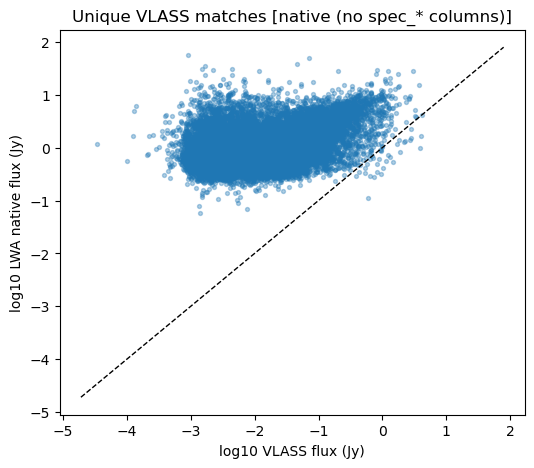

plotted 23865 unique matches (median log10 LWA/VLASS = +1.760)


In [12]:
if USE_CACHED_CROSSMATCH:
    print("Skipping VLASS flux check (USE_CACHED_CROSSMATCH=True)")
else:
    vlass_flux_table = build_unique_flux_table(
        metacatalog,
        vlass_meta_flags,
        vlass_result.vlass_footprint,
        count_col="n_vlass",
        positions_col="vlass_positions",
        ref_freq_hz=VLASS_FREQ_HZ,
        lwa_flux_col="lwa_flux_3ghz_jy",
    )
    print(f"unique VLASS matches: {(vlass_meta_flags['n_vlass'] == 1).sum()}")
    print(f"with LWA native flux: {vlass_flux_table['lwa_flux_jy'].notna().sum()}")
    print(
        "with spectral extrapolation to 3 GHz: "
        f"{vlass_flux_table['lwa_flux_3ghz_jy'].notna().sum()}"
    )
    display(vlass_flux_table.head(20))
    plot_unique_flux_check(
        vlass_flux_table,
        title="Unique VLASS matches",
        lwa_flux_col="lwa_flux_3ghz_jy",
        ref_label="VLASS",
        ref_freq_hz=VLASS_FREQ_HZ,
    )


## Attach surveys as photometric bands

Reuse the loaded reference catalogs as extra frequency channels on the LWA metacatalog (`VLASS`, `NVSS`, `VLSSR`). Unmatched survey sources are dropped. Top-level `RA`/`DEC`/`BMAJ_match` stay on the LWA row; `match_RA` / `match_DEC` / `match_source` record the cascaded bijective survey position (else LWA). Stored flux is the brightest hit preferring `Total_flux` when available (`n_assoc_*` counts every hit).

Skipped when ``USE_CACHED_CROSSMATCH=True``.


In [13]:
if USE_CACHED_CROSSMATCH:
    print("Skipping survey attach (USE_CACHED_CROSSMATCH=True)")
else:
    survey_meta = attach_radio_surveys_to_metacatalog(
        metacatalog,
        surveys={"VLASS": vlass, "NVSS": nvss, "VLSSR": vlssr},
        lwa_radius=LWA_MATCH_RADIUS,
        cascade_bootstrap=True,
        reference_radii={
            "VLASS": VLASS_REFERENCE_RADIUS,
            "NVSS": NVSS_REFERENCE_RADIUS,
            "VLSSR": VLSSR_REFERENCE_RADIUS,
        },
    )
    assert len(survey_meta) == len(metacatalog)
    print(f"LWA rows: {len(survey_meta)} (unchanged)")
    for band in ("VLASS", "NVSS", "VLSSR"):
        n_assoc = survey_meta[f"n_assoc_{band}"]
        n_hit = int((n_assoc >= 1).sum())
        n_multi = int((n_assoc > 1).sum())
        in_bands = survey_meta["bands_present"].astype(str).str.contains(band, regex=False)
        print(
            f"{band:6s}  matched {n_hit:6d}  "
            f"multi {n_multi:5d}  "
            f"in bands_present {int(in_bands.sum()):6d}  "
            f"max n_assoc {int(n_assoc.max())}"
        )
    cols = [
        "meta_id",
        "RA",
        "DEC",
        "match_RA",
        "match_DEC",
        "match_source",
        "origin_band",
        "astrometry_band",
        "bands_present",
        "n_assoc_VLASS",
        "Total_flux_VLASS",
        "Peak_flux_VLASS",
        "n_assoc_NVSS",
        "Total_flux_NVSS",
        "Peak_flux_NVSS",
        "n_assoc_VLSSR",
        "Total_flux_VLSSR",
        "Peak_flux_VLSSR",
    ]
    display(survey_meta[[c for c in cols if c in survey_meta.columns]].head(12))


LWA rows: 252104 (unchanged)
VLASS   matched  50722  multi 34918  in bands_present  50722  max n_assoc 42
NVSS    matched  72123  multi 39244  in bands_present  72123  max n_assoc 42
VLSSR   matched  68994  multi  8166  in bands_present  68994  max n_assoc 17


,meta_id,RA,DEC,match_RA,match_DEC,match_source,origin_band,astrometry_band,bands_present,n_assoc_VLASS,Total_flux_VLASS,Peak_flux_VLASS,n_assoc_NVSS,Total_flux_NVSS,Peak_flux_NVSS,n_assoc_VLSSR,Total_flux_VLSSR,Peak_flux_VLSSR
0,2681,69.235713,29.486041,69.235713,29.486041,LWA,82MHz,82MHz,"82MHz,59MHz,32MHz,27MHz,23MHz,18MHz",0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
1,4138,69.480906,29.510522,69.480906,29.510522,LWA,82MHz,82MHz,"82MHz,59MHz,32MHz,27MHz,23MHz,18MHz,78MHz,64MH...",0,NaN,NaN,13,0.0179,0.0179,0,NaN,NaN
2,258035,68.974885,29.509347,68.994417,29.503222,NVSS,69MHz,69MHz,"27MHz,23MHz,18MHz,64MHz,69MHz,NVSS",0,NaN,NaN,1,0.0029,0.0029,0,NaN,NaN
3,257982,69.231894,29.886232,69.231894,29.886232,LWA,69MHz,69MHz,"69MHz,64MHz,59MHz,55MHz,36MHz,32MHz,18MHz",0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
4,261340,6.054178,64.432851,6.054178,64.432851,LWA,69MHz,69MHz,"18MHz,69MHz,NVSS",0,NaN,NaN,9,0.0762,0.0762,0,NaN,NaN
5,178631,260.351522,-1.022700,260.351522,-1.022700,LWA,78MHz,78MHz,"27MHz,23MHz,78MHz,64MHz,73MHz,50MHz,41MHz,NVSS",0,NaN,NaN,14,0.0725,0.0725,0,NaN,NaN
6,30253,303.237997,23.476486,303.237997,23.476486,LWA,82MHz,82MHz,"82MHz,73MHz,64MHz,55MHz,46MHz,41MHz,18MHz",0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
7,179469,303.326568,23.650336,303.326568,23.650336,LWA,78MHz,78MHz,"78MHz,69MHz,50MHz,23MHz,18MHz",0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
8,186903,303.315209,23.380789,303.315209,23.380789,LWA,78MHz,78MHz,"78MHz,64MHz,55MHz,50MHz,46MHz,41MHz,18MHz",0,NaN,NaN,0,NaN,NaN,0,NaN,NaN
9,3961,303.293246,23.797484,303.293246,23.797484,LWA,82MHz,82MHz,"82MHz,78MHz,73MHz,69MHz,64MHz,59MHz,50MHz,46MH...",0,NaN,NaN,0,NaN,NaN,0,NaN,NaN


## Write cross-matched catalog

Writes `metacatalog_radio.parquet` (LWA metacatalog + attached `Total_flux_{VLSSR,NVSS,VLASS}` / `Peak_flux_*` / `n_assoc_*`, plus `match_RA` / `match_DEC` / `match_source` from the cascaded match frame). Top-level `RA`/`DEC` remain LWA. Set `WRITE_CROSSMATCH = True` in the config cell.

Downstream: `metacatalog_association_qc_summary.ipynb` reads `n_assoc_*` for radio match-count statistics; `metacatalog_spectral_modeling.ipynb` can load this file with `INCLUDE_SURVEY_FLUXES = True` to fit SEDs that include survey photometry.

Skipped when ``USE_CACHED_CROSSMATCH=True`` (also respects ``WRITE_CROSSMATCH``).


In [14]:
if USE_CACHED_CROSSMATCH:
    print("Skipping write (USE_CACHED_CROSSMATCH=True)")
else:
    CROSSMATCH_OUTPUT = layout.metacatalog_radio()
    if WRITE_CROSSMATCH:
        write_table(survey_meta, CROSSMATCH_OUTPUT, include_extras=True)
        print(f"Wrote {CROSSMATCH_OUTPUT.resolve()}")
        print(f"rows={len(survey_meta):,}  cols={len(survey_meta.columns)}")
    else:
        print("Skipping write (WRITE_CROSSMATCH=False)")


Wrote /fast/claw/metacatalog_coaddR-0.75_subband2/metacatalog_radio.parquet
rows=252,104  cols=132


## Visual QA (linked table + sky)

Browse radio cross-match columns and verify LWA↔survey associations on HiPS.

With ``USE_CACHED_CROSSMATCH = True`` (config cell), this section loads ``metacatalog_radio.parquet`` only — run **config + Visual QA**; skip match/attach/write. With ``False``, prefers in-memory ``survey_meta`` after attach (falls back to the parquet).

1. Default path is ``layout.metacatalog_radio()``. Override ``RADIO_QA_PATH`` if needed.
2. Optionally set ``RADIO_QA_FILTER`` to a boolean Series, Index, or label array (pandas) to subset rows — e.g. good spectral fits or ``n_assoc_NVSS >= 1``.
3. Select a table row, choose an **Image survey** (LWA / VLSSR / NVSS / VLASS), then **Load sky view**.
4. **Overlay catalog follows the image survey:** LWA → metacatalog beams; VLSSR/NVSS/VLASS → that survey’s reference catalog at its restoring beam (lazy-loaded from ``VLSSR_PATH`` / ``NVSS_PATH`` / ``VLASS_PATH``). A yellow marker marks the selected metacatalog row.
5. When **LWA** is selected, pick any HiPS product from the local/list server dropdown.

**VLASS HiPS:** uses the official Quicklook Median Stack (`NRAO/P/VLASS-Quicklook-MedianStack` → `https://vlass-dl.nrao.edu/vlass/HiPS/MedianStack/Quicklook/`). NRAO’s VLASS image cache is sometimes offline; if VLASS looks identical to NVSS, tile fetches failed and Aladin kept the previous survey — set `SURVEY_HIPS_OVERRIDES["VLASS"]` to a local mirror when available.

Beam markers are redrawn when you change **Image survey**. VLSSR (80″) vs NVSS (45″) differences are subtle at 10° FOV — zoom in to compare. Marker color should also change (VLSSR orange, NVSS cyan, VLASS magenta).


In [15]:
from __future__ import annotations

import re
import threading
from pathlib import Path

import astropy.units as u
import numpy as np
import pandas as pd
import panel as pn
import param
from astropy.coordinates import SkyCoord
from IPython.display import Javascript, display

from lwa_catalog.analyze import load_nvss_catalog, load_vlass_catalog, load_vlssr_catalog
from lwa_catalog.io import read_table
from lwa_catalog.viz import (
    DebouncedAladinViewRefresh,
    aladin_view_center_fov,
    catalog_name_from_file,
    catalog_with_survey_beam,
    clear_catalog_overlays,
    default_hips_survey,
    discover_local_hips_surveys,
    fetch_hips_surveys,
    hips_survey_url,
    overlay_catalog_by_band,
    survey_hips_url,
    VLASS_MEDIAN_HIPS_ID,
)

pn.extension("tabulator", notifications=True)

# --- Visual QA config -------------------------------------------------------
# Data source follows USE_CACHED_CROSSMATCH from the notebook config cell.
RADIO_QA_PATH = layout.metacatalog_radio()
# Optional row filter: None | boolean Series aligned to index | Index | label array
# Examples (uncomment one):
# RADIO_QA_FILTER = None
# RADIO_QA_FILTER = radio_df["n_assoc_NVSS"] >= 1          # after load below
# RADIO_QA_FILTER = radio_df.query("n_assoc_VLASS >= 1 and Total_flux_NVSS > 0.05").index
RADIO_QA_FILTER = None

HIPS_LIST_SERVER = "http://lwacalim10:3005"
HIPS_SERVER = "http://localhost:3005"
DEFAULT_HIPS_SURVEY = (
    "Blue_I_deep_Taper_Robust-0.75_pbcorr_coadd_mosaic_jysr_feather_allsky_20241218-20250823_N023.hips"
)
SKY_FOV_DEG = 10.0  # degrees; re-applied after HiPS load (surveys may set hips_initial_fov)
HIPS_VIEW_HEIGHT = 500
OVERLAY_MAX_SOURCES_DEFAULT = 500
TABLE_HEIGHT = 420
TABLE_PAGE_SIZE = 50
MAX_TABLE_COLUMNS = 40

# Optional HiPS URL / Aladin-ID overrides (merged into survey_hips_url).
# Official VLASS median stack: VLASS_MEDIAN_HIPS_ID or
#   https://vlass-dl.nrao.edu/vlass/HiPS/MedianStack/Quicklook/
# Example local mirror: SURVEY_HIPS_OVERRIDES = {"VLASS": "http://localhost:8000/VLASS_MedianStack.hips/"}
SURVEY_HIPS_OVERRIDES: dict[str, str] = {
    # Prefer the CDS/Aladin registry ID for the Quicklook Median Stack:
    "VLASS": VLASS_MEDIAN_HIPS_ID,
}

IMAGE_SURVEYS = ("LWA", "VLSSR", "NVSS", "VLASS")
SURVEY_MARKER_COLORS = {
    "LWA": None,  # band-colored
    "VLSSR": "#ff9800",
    "NVSS": "#00bcd4",
    "VLASS": "#e040fb",
}

CROSSMATCH_PREFERRED_COLUMNS = [
    "meta_id",
    "RA",
    "DEC",
    "match_RA",
    "match_DEC",
    "match_source",
    "origin_band",
    "astrometry_band",
    "n_assoc_VLSSR",
    "Peak_flux_VLSSR",
    "Total_flux_VLSSR",
    "n_assoc_NVSS",
    "Peak_flux_NVSS",
    "Total_flux_NVSS",
    "n_assoc_VLASS",
    "Peak_flux_VLASS",
    "Total_flux_VLASS",
    "Maj",
    "Min",
    "PA",
    "spec_model_chi2_red",
    "spec_model_bic",
    "spec_model_n_terms",
]

print("USE_CACHED_CROSSMATCH =", USE_CACHED_CROSSMATCH)
print("RADIO_QA_PATH =", Path(RADIO_QA_PATH).resolve())
print("exists:", Path(RADIO_QA_PATH).is_file())
print("VLASS HiPS:", survey_hips_url("VLASS", overrides=SURVEY_HIPS_OVERRIDES))
print("VLASS median ID:", VLASS_MEDIAN_HIPS_ID)
print("SKY_FOV_DEG =", SKY_FOV_DEG)


NotificationArea()

USE_CACHED_CROSSMATCH = False
RADIO_QA_PATH = /fast/claw/metacatalog_coaddR-0.75_subband2/metacatalog_radio.parquet
exists: True
VLASS HiPS: NRAO/P/VLASS-Quicklook-MedianStack
VLASS median ID: NRAO/P/VLASS-Quicklook-MedianStack
SKY_FOV_DEG = 10.0


In [16]:
def apply_radio_qa_filter(
    df: pd.DataFrame,
    row_filter: pd.Series | pd.Index | np.ndarray | list | None,
) -> pd.DataFrame:
    """Subset *df* with a pandas boolean mask, Index, or label array."""
    if row_filter is None:
        return df.copy()
    if isinstance(row_filter, pd.Series):
        if not pd.api.types.is_bool_dtype(row_filter):
            raise TypeError("RADIO_QA_FILTER Series must be boolean")
        aligned = row_filter.reindex(df.index)
        if aligned.isna().any():
            missing = int(aligned.isna().sum())
            raise ValueError(
                f"RADIO_QA_FILTER boolean Series has {missing} index labels "
                "not present in the radio catalog"
            )
        return df.loc[aligned.astype(bool)].copy()
    if isinstance(row_filter, pd.Index):
        missing = row_filter.difference(df.index)
        if len(missing):
            raise ValueError(
                f"RADIO_QA_FILTER Index has {len(missing)} labels not in the catalog"
            )
        return df.loc[row_filter].copy()
    labels = pd.Index(row_filter)
    missing = labels.difference(df.index)
    if len(missing):
        raise ValueError(
            f"RADIO_QA_FILTER labels have {len(missing)} entries not in the catalog"
        )
    return df.loc[labels].copy()


if USE_CACHED_CROSSMATCH:
    if not Path(RADIO_QA_PATH).is_file():
        raise FileNotFoundError(
            f"USE_CACHED_CROSSMATCH=True but missing {Path(RADIO_QA_PATH).resolve()}. "
            "Run the match/attach/write cells with WRITE_CROSSMATCH=True first."
        )
    radio_df_full = read_table(RADIO_QA_PATH)
    print(
        f"cached crossmatch: {len(radio_df_full):,} rows × {len(radio_df_full.columns)} cols "
        f"← {Path(RADIO_QA_PATH).resolve()}"
    )
elif "survey_meta" in globals() and isinstance(survey_meta, pd.DataFrame) and not survey_meta.empty:
    radio_df_full = survey_meta.copy()
    print(
        f"in-memory survey_meta: {len(radio_df_full):,} rows × {len(radio_df_full.columns)} cols "
        "(USE_CACHED_CROSSMATCH=False)"
    )
else:
    if not Path(RADIO_QA_PATH).is_file():
        raise FileNotFoundError(
            f"No in-memory survey_meta and missing {Path(RADIO_QA_PATH).resolve()}. "
            "Run attach/write or set USE_CACHED_CROSSMATCH=True after a prior write."
        )
    radio_df_full = read_table(RADIO_QA_PATH)
    print(
        f"fallback parquet: {len(radio_df_full):,} rows × {len(radio_df_full.columns)} cols "
        f"← {Path(RADIO_QA_PATH).resolve()}"
    )

# Re-bind filter examples that referenced radio_df before load:
# RADIO_QA_FILTER = radio_df_full["n_assoc_NVSS"] >= 1
# RADIO_QA_FILTER = radio_df_full.query("spec_model_chi2_red < 2").index

radio_df = apply_radio_qa_filter(radio_df_full, RADIO_QA_FILTER)
print(f"after RADIO_QA_FILTER: {len(radio_df):,} rows")
if radio_df.empty:
    raise ValueError("Filtered radio catalog is empty; relax RADIO_QA_FILTER")


in-memory survey_meta: 252,104 rows × 132 cols (USE_CACHED_CROSSMATCH=False)
after RADIO_QA_FILTER: 252,104 rows


In [17]:
import re
_COMPARE_FILTER_INSTALL_JS = r"""
(function () {
  function install(T) {
    if (!T || T.__lwaCompareFilter) return !!T;
    T.__lwaCompareFilter = true;
    T.extendModule("filter", "filters", {
      compare: function (headerValue, rowValue, rowData, filterParams) {
        if (headerValue === null || headerValue === undefined || headerValue === '') {
          return true;
        }
        if (rowValue === null || rowValue === undefined || rowValue === '') {
          return false;
        }
        var s = String(headerValue).trim();
        var m = s.match(/^(<=|>=|<|>|!=|==|=)?\s*([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)\s*$/);
        if (!m) {
          return true;
        }
        var op = m[1] || '>=';
        if (op === '==') op = '=';
        var thr = parseFloat(m[2]);
        var v = Number(rowValue);
        if (Number.isNaN(v) || Number.isNaN(thr)) return false;
        switch (op) {
          case '>':  return v > thr;
          case '>=': return v >= thr;
          case '<':  return v < thr;
          case '<=': return v <= thr;
          case '!=': return v !== thr;
          case '=':  return v === thr;
          default:   return v >= thr;
        }
      }
    });
    return true;
  }
  function tryInstall() {
    if (window.Tabulator && install(window.Tabulator)) return true;
    return false;
  }
  if (!tryInstall()) {
    var n = 0;
    var id = setInterval(function () {
      if (tryInstall() || ++n > 400) clearInterval(id);
    }, 25);
  }
})();
"""
display(Javascript(_COMPARE_FILTER_INSTALL_JS))


def header_filters_for(df: pd.DataFrame) -> dict[str, dict]:
    filters: dict[str, dict] = {}
    for col in df.columns:
        kind = df[col].dtype.kind
        if kind in "iuf":
            filters[col] = {
                "type": "input",
                "func": "compare",
                "placeholder": ">5 / <=8.1",
            }
        elif kind == "b":
            filters[col] = {"type": "tickCross", "tristate": True, "indeterminateValue": None}
        else:
            filters[col] = {"type": "input", "func": "like", "placeholder": "contains…"}
    return filters


_COMPARE_HEADER_RE = re.compile(
    r"^(<=|>=|<|>|!=|==|=)?\s*([+-]?(?:\d+\.?\d*|\.\d+)(?:[eE][+-]?\d+)?)\s*$"
)


def _normalize_compare_filters(filters: list) -> list:
    out: list = []
    for filt in filters:
        if not isinstance(filt, dict) or filt.get("type") != "compare":
            out.append(filt)
            continue
        raw = filt.get("value")
        if raw is None or raw == "":
            continue
        match = _COMPARE_HEADER_RE.match(str(raw).strip())
        if not match:
            continue
        op = match.group(1) or ">="
        if op in ("==", "="):
            op = "="
        out.append({**filt, "type": op, "value": match.group(2)})
    return out


class _HeaderFilterOwner:
    def __init__(self, *, filters, header_filters, indexes, value):
        self.filters = filters
        self.header_filters = header_filters
        self.indexes = indexes
        self.value = value


class RadioQATabulator(pn.widgets.Tabulator):
    """Remote-pagination Tabulator with numeric ``compare`` header filters."""

    def _get_header_filters(self, df: pd.DataFrame) -> list:
        holder = _HeaderFilterOwner(
            filters=_normalize_compare_filters(list(getattr(self, "filters", []) or [])),
            header_filters=self.header_filters,
            indexes=self.indexes,
            value=self.value,
        )
        return pn.widgets.Tabulator._get_header_filters(holder, df)


def _hide_from_default_table(col: str) -> bool:
    """Columns omitted from the default Tabulator view (still selectable)."""
    if col in {"bands_present", "quality_flag"}:
        return True
    if col.startswith(("DC_", "BMAJ_", "resid_")):
        return True
    # Band fluxes/errors: Peak_flux_18MHz, Total_flux_41MHz, E_*_flux_*MHz.
    # Keep survey peaks/totals: Peak_flux_VLSSR, Total_flux_NVSS, etc.
    return bool(re.search(r"(?:E_)?(?:Peak|Total)_flux_\d+MHz$", col))


def preferred_display_columns(df: pd.DataFrame) -> list[str]:
    preferred = [
        c
        for c in CROSSMATCH_PREFERRED_COLUMNS
        if c in df.columns and not _hide_from_default_table(c)
    ]
    rest = sorted(
        c
        for c in df.columns
        if c not in preferred and not _hide_from_default_table(c)
    )
    cols = preferred + rest
    return cols[:MAX_TABLE_COLUMNS]


def fetch_lwa_hips_surveys(catalog_dir: Path) -> list[str]:
    local = discover_local_hips_surveys(catalog_dir)
    fallback = default_hips_survey(local or [DEFAULT_HIPS_SURVEY], default_survey=DEFAULT_HIPS_SURVEY)
    return fetch_hips_surveys(
        HIPS_LIST_SERVER,
        catalog_dir=catalog_dir,
        default_survey=fallback,
    )



_QA_OVERLAY_PREFIXES = tuple(f"catalog_{s}" for s in IMAGE_SURVEYS) + ("catalog", "catalog_sel")


def _clear_qa_overlays(aladin) -> None:
    """Remove all Visual-QA catalog overlay layers (any image-survey prefix)."""
    for prefix in _QA_OVERLAY_PREFIXES:
        clear_catalog_overlays(aladin, name_prefix=prefix)


class RadioCrossmatchSkyQA(pn.viewable.Viewer):
    """Linked radio-crossmatch table + Aladin HiPS verification widget."""

    image_survey = param.Selector(default="LWA", objects=list(IMAGE_SURVEYS))
    show_overlay = param.Boolean(default=True)
    max_sources = param.Integer(default=OVERLAY_MAX_SOURCES_DEFAULT, bounds=(100, 2000))
    display_columns = param.ListSelector(default=[], objects=[])

    def __init__(self, df: pd.DataFrame, *, catalog_dir: Path, **params):
        params = dict(params)
        params.pop("display_columns", None)
        params.pop("image_survey", None)
        super().__init__(**params)

        self._ready = False
        self._df = df.reset_index(drop=True).copy()
        self._catalog_dir = Path(catalog_dir)
        # Lazy-loaded reference catalogs for VLSSR/NVSS/VLASS overlays.
        self._survey_catalogs: dict[str, pd.DataFrame] = {}
        self._overlay_lock = threading.RLock()
        self._sky_loaded = False
        self._sky_center_note = ""
        self._overlay_note = ""

        cols = preferred_display_columns(self._df)
        self.param.display_columns.objects = list(self._df.columns)
        self.display_columns = cols

        with pn.config.set(sizing_mode="stretch_width"):
            self._cols_w = pn.widgets.MultiChoice.from_param(
                self.param.display_columns,
                name="Display columns",
                placeholder="Select columns…",
                solid=False,
                option_limit=80,
                search_option_limit=80,
            )
            self._status = pn.pane.Markdown(
                f"**{len(self._df):,}** rows from `{RADIO_QA_PATH.name}`",
                sizing_mode="stretch_width",
            )
            self._table = RadioQATabulator(
                self._df.loc[:, cols],
                pagination="remote",
                page_size=TABLE_PAGE_SIZE,
                height=TABLE_HEIGHT,
                sizing_mode="stretch_width",
                layout="fit_columns",
                header_filters=header_filters_for(self._df.loc[:, cols]),
                show_index=False,
                disabled=True,
                sortable=True,
                selectable=1,
                configuration={"filterMode": "remote"},
            )
            self._table.param.watch(self._on_table_select, "selection")

            self._survey_w = pn.widgets.RadioButtonGroup.from_param(
                self.param.image_survey,
                name="Image survey",
                button_type="primary",
            )
            hips_surveys = fetch_lwa_hips_surveys(self._catalog_dir)
            hips_default = (
                DEFAULT_HIPS_SURVEY
                if DEFAULT_HIPS_SURVEY in hips_surveys
                else default_hips_survey(hips_surveys, default_survey=DEFAULT_HIPS_SURVEY)
            )
            self._hips_survey_w = pn.widgets.Select(
                name="LWA HiPS survey",
                options=hips_surveys,
                value=hips_default,
                sizing_mode="stretch_width",
                disabled=False,
            )
            self._sky_btn = pn.widgets.Button(
                name="Load sky view",
                button_type="primary",
                width=150,
                sizing_mode="fixed",
            )
            self._sky_btn.on_click(self._on_load_sky)
            self._overlay_w = pn.widgets.Checkbox.from_param(
                self.param.show_overlay,
                name="Show beam markers",
            )
            self._max_sources_w = pn.widgets.IntInput.from_param(
                self.param.max_sources,
                name="Max markers in FOV",
                width=140,
            )
            self._hips_status = pn.pane.Markdown(
                "_Select a row, choose an image survey, then **Load sky view**._",
                sizing_mode="stretch_width",
                height=48,
            )

            init_coord = self._default_coord()
            from ipyaladin import Aladin

            self._hips_current_url = self._resolve_hips_url()
            self._aladin = Aladin(
                survey=self._hips_current_url,
                target=init_coord,
                fov=float(SKY_FOV_DEG),
                height=HIPS_VIEW_HEIGHT,
            )
            self._fov_timers: list = []
            self._overlay_refresh = None
            self._overlay_refresh_paused = False
            self._hips_view = pn.pane.IPyWidget(
                self._aladin,
                height=HIPS_VIEW_HEIGHT + 20,
                sizing_mode="stretch_width",
            )
            # HiPS load can override constructor FOV with hips_initial_fov.
            self._apply_sky_fov(deferred=True)
            self._overlay_refresh = DebouncedAladinViewRefresh(
                self._aladin,
                self._refresh_overlay_from_aladin,
                enabled=lambda: self._ready and self.show_overlay and self._sky_loaded,
            )
            self._hips_survey_w.param.watch(self._on_lwa_hips_change, "value")
            self._overlay_w.param.watch(self._on_overlay_change, "value")
            self.param.watch(self._on_overlay_change, "max_sources")
            self.param.watch(self._on_image_survey_change, "image_survey")
            self.param.watch(self._on_columns_change, "display_columns")

            self._panel = pn.Column(
                self._cols_w,
                self._status,
                self._table,
                pn.pane.Markdown("### Sky context (HiPS + beam markers)", disable_anchors=True),
                pn.Row(self._survey_w, sizing_mode="stretch_width", height=40),
                pn.Row(self._hips_survey_w, self._sky_btn, align="end", height=50),
                pn.Row(self._overlay_w, self._max_sources_w, align="center", height=40),
                self._hips_status,
                self._hips_view,
            )

        self._ready = True
        self._sync_lwa_hips_enabled()
        if len(self._df):
            self._table.selection = [0]

    def __panel__(self):
        return self._panel

    def _default_coord(self) -> SkyCoord:
        row = self._df.iloc[0]
        coord = self._row_sky_coord(row)
        if coord is not None:
            return coord
        return SkyCoord(ra=83.633 * u.deg, dec=-5.391 * u.deg, frame="icrs")

    def _row_sky_coord(self, row: pd.Series) -> SkyCoord | None:
        try:
            ra = float(row["RA"])
            dec = float(row["DEC"])
        except (KeyError, TypeError, ValueError):
            return None
        if not (np.isfinite(ra) and np.isfinite(dec)):
            return None
        return SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")

    def _set_sky_center_note(self, text: str) -> None:
        self._sky_center_note = text
        self._update_hips_status()

    def _set_overlay_note(self, text: str) -> None:
        self._overlay_note = text
        self._update_hips_status()

    def _update_hips_status(self) -> None:
        parts = [p for p in (self._sky_center_note, self._overlay_note) if p]
        self._hips_status.object = " ".join(parts) if parts else ""

    def _resolve_hips_url(self) -> str:
        survey = str(self.image_survey)
        if survey == "LWA":
            return hips_survey_url(str(self._hips_survey_w.value), base=HIPS_SERVER)
        return survey_hips_url(survey, overrides=SURVEY_HIPS_OVERRIDES)

    def _sync_lwa_hips_enabled(self) -> None:
        self._hips_survey_w.disabled = str(self.image_survey) != "LWA"

    def _pause_overlay_refresh(self) -> None:
        """Temporarily ignore Aladin pan/zoom overlay callbacks."""
        self._overlay_refresh_paused = True
        refresh = getattr(self, "_overlay_refresh", None)
        if refresh is not None:
            refresh.cancel_pending()

    def _resume_overlay_refresh(self) -> None:
        self._overlay_refresh_paused = False

    def _apply_sky_fov(self, *, deferred: bool = True) -> None:
        """Force Aladin FOV to ``SKY_FOV_DEG`` without layout thrash.

        VLSSR HiPS publishes ``hips_initial_fov`` ~34° and can re-apply it while
        tiles load. Fighting that with repeated FOV sets retriggered overlay
        refresh and Panel button resizing. Pause overlay refresh, set FOV once,
        and optionally re-assert once after tiles settle.
        """
        fov = float(SKY_FOV_DEG)

        def _set_if_needed() -> None:
            try:
                current = float(self._aladin.fov.to(u.deg).value)
            except Exception:
                current = float("nan")
            if np.isfinite(current) and abs(current - fov) < 0.05:
                return
            try:
                self._aladin.fov = fov
            except Exception:
                pass

        self._pause_overlay_refresh()
        _set_if_needed()

        for t in list(getattr(self, "_fov_timers", []) or []):
            try:
                t.cancel()
            except Exception:
                pass
        self._fov_timers = []

        if not deferred:
            self._resume_overlay_refresh()
            return

        def _reassert() -> None:
            try:
                _set_if_needed()
            finally:
                self._resume_overlay_refresh()

        t = threading.Timer(0.5, _reassert)
        t.daemon = True
        t.start()
        self._fov_timers = [t]

    def _apply_hips_url(self) -> None:
        url = self._resolve_hips_url()
        changed = url != self._hips_current_url
        if changed:
            self._aladin.survey = url
            self._hips_current_url = url
        # Restore operator FOV (VLSSR initial FOV is ~34°).
        self._apply_sky_fov(deferred=changed)

    def _selected_table_row(self) -> pd.Series | None:
        if not self._table.selection:
            return None
        idx = int(self._table.selection[0])
        view = self._table.value
        if view is None or not (0 <= idx < len(view)):
            return None
        # Map from displayed view row back to self._df via meta_id when possible
        row = view.iloc[idx]
        if "meta_id" in row.index and "meta_id" in self._df.columns:
            hits = self._df.index[self._df["meta_id"] == row["meta_id"]].tolist()
            if hits:
                return self._df.loc[hits[0]]
        if 0 <= idx < len(self._df):
            return self._df.iloc[idx]
        return row

    def _overlay_selection_iloc(self) -> int | None:
        row = self._selected_table_row()
        if row is None:
            return None
        if "meta_id" in row.index and "meta_id" in self._df.columns and pd.notna(row.get("meta_id")):
            matches = np.flatnonzero(
                self._df["meta_id"].to_numpy() == row["meta_id"]
            )
            if len(matches):
                return int(matches[0])
        if self._table.selection:
            idx = int(self._table.selection[0])
            if 0 <= idx < len(self._df):
                return idx
        return None

    def _on_columns_change(self, *_events) -> None:
        if not self._ready:
            return
        cols = [c for c in self.display_columns if c in self._df.columns]
        if not cols:
            cols = preferred_display_columns(self._df)
        sel = list(self._table.selection) if self._table.selection else []
        self._table.header_filters = header_filters_for(self._df.loc[:, cols])
        self._table.value = self._df.loc[:, cols]
        if sel:
            self._table.selection = sel

    def _on_table_select(self, _event=None) -> None:
        if not self._ready:
            return
        row = self._selected_table_row()
        if row is None:
            return
        if self._sky_loaded:
            try:
                self._refresh_overlay()
            except Exception as exc:
                self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _on_image_survey_change(self, *_events) -> None:
        if not self._ready:
            return
        self._sync_lwa_hips_enabled()
        # Survey URL change re-asserts FOV inside _apply_hips_url.
        self._apply_hips_url()
        if self._sky_loaded:
            try:
                self._refresh_overlay()
            except Exception as exc:
                self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")
        else:
            _clear_qa_overlays(self._aladin)
            self._set_overlay_note(
                f"Image survey → **{self.image_survey}** "
                "(click **Load sky view** to draw beam markers)."
            )

    def _on_lwa_hips_change(self, _event=None) -> None:
        if not self._ready or str(self.image_survey) != "LWA":
            return
        self._apply_hips_url()
        self._apply_sky_fov(deferred=True)

    def _on_overlay_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _on_load_sky(self, _event=None) -> None:
        row = self._selected_table_row()
        if row is None:
            self._hips_status.object = "**Select a table row first.**"
            return
        coord = self._row_sky_coord(row)
        if coord is None:
            self._hips_status.object = "**Selected row missing finite RA/DEC.**"
            return
        self._sky_loaded = True
        self._apply_hips_url()
        self._aladin.target = coord
        self._apply_sky_fov(deferred=True)
        label = ""
        if "meta_id" in row.index and pd.notna(row.get("meta_id")):
            label = f"**meta_id={int(row['meta_id'])}** — "
        self._set_sky_center_note(
            f"{label}RA={coord.ra.deg:.6f}, Dec={coord.dec.deg:.6f} "
            f"(FOV={SKY_FOV_DEG:.2f}°, image={self.image_survey})."
        )
        try:
            self._refresh_overlay(coord, fov_deg=float(SKY_FOV_DEG))
        except Exception as exc:
            self._set_overlay_note(f"**Overlay failed:** `{exc}`")


    def _ensure_survey_catalog(self, survey: str) -> pd.DataFrame:
        """Load and cache the reference catalog for *survey* (VLSSR/NVSS/VLASS)."""
        key = str(survey).strip().upper()
        cached = self._survey_catalogs.get(key)
        if cached is not None:
            return cached
        self._set_overlay_note(f"_Loading {key} reference catalog…_")
        if key == "VLSSR":
            cat = load_vlssr_catalog(VLSSR_PATH)
        elif key == "NVSS":
            cat = load_nvss_catalog(NVSS_PATH)
        elif key == "VLASS":
            cat = load_vlass_catalog(VLASS_PATH, config=vlass_config)
        else:
            raise ValueError(f"no reference catalog loader for {survey!r}")
        # Keep columns needed for overlays; origin_band drives a single color group.
        out = cat.copy()
        if "origin_band" not in out.columns:
            out["origin_band"] = key
        self._survey_catalogs[key] = out
        print(f"Loaded {key} reference catalog: {len(out):,} rows")
        return out

    def _overlay_dataframe(self, survey: str) -> tuple[pd.DataFrame, str, int | None]:
        """Return (catalog, catalog_name, selection_idx) for the image-survey overlay."""
        key = str(survey).strip().upper()
        if key == "LWA":
            return (
                catalog_with_survey_beam(self._df, "LWA"),
                catalog_name_from_file(Path(RADIO_QA_PATH).name),
                self._overlay_selection_iloc(),
            )
        ref = self._ensure_survey_catalog(key)
        return catalog_with_survey_beam(ref, key), key.lower(), None

    def _draw_selected_meta_marker(self, coord: SkyCoord, fov_deg: float) -> None:
        """Mark the selected metacatalog row on top of a survey-catalog overlay."""
        row = self._selected_table_row()
        if row is None:
            return
        try:
            ra = float(row["RA"])
            dec = float(row["DEC"])
        except (KeyError, TypeError, ValueError):
            return
        if not (np.isfinite(ra) and np.isfinite(dec)):
            return
        sel = pd.DataFrame(
            {
                "RA": [ra],
                "DEC": [dec],
                "Maj": [float(row["Maj"]) if "Maj" in row.index and pd.notna(row.get("Maj")) else np.nan],
                "Min": [float(row["Min"]) if "Min" in row.index and pd.notna(row.get("Min")) else np.nan],
                "PA": [float(row["PA"]) if "PA" in row.index and pd.notna(row.get("PA")) else np.nan],
                "origin_band": ["Full"],
                "meta_id": [row.get("meta_id", -1)],
            }
        )
        overlay_catalog_by_band(
            self._aladin,
            sel,
            "metacatalog",
            coord,
            float(fov_deg),
            name_prefix="catalog_sel",
            max_rows=1,
            selection_idx=0,
            color="#ffeb3b",
            replace=True,
        )

    def _refresh_overlay_from_aladin(self) -> None:
        if not self._ready or getattr(self, "_overlay_refresh_paused", False):
            return
        try:
            with self._overlay_lock:
                self._refresh_overlay()
        except Exception as exc:
            self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _refresh_overlay(
        self,
        coord: SkyCoord | None = None,
        *,
        fov_deg: float | None = None,
    ) -> None:
        with self._overlay_lock:
            if self._overlay_refresh is not None:
                self._overlay_refresh.cancel_pending()
            if coord is None or fov_deg is None:
                view_coord, view_fov = aladin_view_center_fov(self._aladin)
                coord = coord or view_coord
                fov_deg = fov_deg if fov_deg is not None else view_fov

            survey = str(self.image_survey)
            catalog_name = catalog_name_from_file(Path(RADIO_QA_PATH).name)
            fov = float(fov_deg)

            # Always drop prior survey layers first (stale VLSSR ellipses otherwise
            # remain when switching to a smaller beam like NVSS/VLASS).
            _clear_qa_overlays(self._aladin)

            if not self.show_overlay:
                self._set_overlay_note("Markers off.")
                return

            beam_df, catalog_name, selection_idx = self._overlay_dataframe(survey)
            prefix = f"catalog_{survey}"
            result = overlay_catalog_by_band(
                self._aladin,
                beam_df,
                catalog_name,
                coord,
                fov,
                name_prefix=prefix,
                max_rows=int(self.max_sources),
                selection_idx=selection_idx,
                color=SURVEY_MARKER_COLORS.get(survey),
            )
            if survey != "LWA":
                self._draw_selected_meta_marker(coord, fov)
            cap_note = f" (capped at {self.max_sources})" if result.truncated else ""
            beam_note = {
                "LWA": "metacatalog Maj/Min/PA",
                "VLSSR": "VLSSR catalog @ 80″",
                "NVSS": "NVSS catalog @ 45″",
                "VLASS": "VLASS catalog @ 2.5″",
            }.get(survey, survey)
            color = SURVEY_MARKER_COLORS.get(survey) or "band colors"
            src_note = "metacatalog" if survey == "LWA" else f"{survey} reference catalog"
            self._set_overlay_note(
                f"Markers **{survey}** ({src_note}): {result.drawn} drawn, "
                f"{result.in_fov} in FOV{cap_note} — {beam_note}, color=`{color}`."
            )


sky_qa = RadioCrossmatchSkyQA(radio_df, catalog_dir=layout.root)
sky_qa


<IPython.core.display.Javascript object>

RadioCrossmatchSkyQA(display_columns=['meta_id', 'RA', 'DEC', 'match_RA', 'match_DEC', 'match_source', 'origin_band', 'astrometry_band', 'n_assoc_VLSSR', 'Peak_flux_VLSSR', 'Total_flux_VLSSR', 'n_assoc_NVSS', 'Peak_flux_NVSS', 'Total_flux_NVSS', 'n_assoc_VLASS', 'Peak_flux_VLASS', 'Total_flux_VLASS', 'Maj', 'Min', 'PA', 'E_Peak_flux_NVSS', 'E_Peak_flux_VLASS', 'E_Peak_flux_VLSSR', 'E_Total_flux_NVSS', 'E_Total_flux_VLASS', 'E_Total_flux_VLSSR', 'Resid_Isl_mean', 'Resid_Isl_rms', 'cluster_jitter_rms_deg', 'lst_hours', 'match_sigma_deg', 'n_assoc_18MHz', 'n_assoc_23MHz', 'n_assoc_27MHz', 'n_assoc_32MHz', 'n_assoc_36MHz', 'n_assoc_41MHz', 'n_assoc_46MHz', 'n_assoc_50MHz', 'n_assoc_55MHz'], image_survey='LWA', max_sources=500, name='RadioCrossmatchSkyQA00124', show_overlay=True)